# Breathe Detection Project - ML Modeling
Goal of this Jupyter Notebook is to analyze temperature and pressure data for the Breathe Detection project, and then build a ML model.
The notebook will first load the data, visualize some samples, perform some statistical analysis and preprocess the data to extract additional useful informaiton.
Ultimate goal is to train a Breathe Detection model for PSOC 6 AI Kit able to run in real time.

In [1]:
# Import useful libraries (Pandas for loading files, matplotlib for visualization, os for navigating files and folders)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow
from tensorflow.keras.utils import to_categorical
from src.data_management import extract_windows_with_labels

# Set autoreloading to make changes to external files
%load_ext autoreload
%autoreload 2

## Load data from .data files on disk

In [2]:
data_folder = "Data (Precise label)"
data_filename = "DPS-Data-With-Additional-Features.data"
label_filename = "Live-Labeling.label"

from src.data_management import load_index_dataframe

data_index_df = load_index_dataframe(data_folder, data_filename = data_filename, label_filename = label_filename)


In [3]:
# Access all train and test samples
train_rows = data_index_df[(data_index_df.set == "train")]
test_rows = data_index_df[(data_index_df.set == "test")]

In [4]:
# Build lists from training and test samples:

train_data_df_list = []
train_label_df_list = []
for i, sample in train_rows.iterrows():
    train_data_df_list.append(pd.read_csv(sample['data_path']))
    train_label_df_list.append(pd.read_csv(sample['labels_path']))

test_data_df_list = []
test_label_df_list = []
for i, sample in test_rows.iterrows():
    test_data_df_list.append(pd.read_csv(sample['data_path']))
    test_label_df_list.append(pd.read_csv(sample['labels_path']))
    
print(f"Loaded {len(train_data_df_list)} training samples and {len(test_data_df_list)} test samples.")

Loaded 72 training samples and 39 test samples.


## ML Models Training

In [5]:
# This code will analyz each data sample, and it will extract windows from the available data. This is th logic applied:
# - Data is windowed sequentially with specified window size and overlap;
# - Each window is associated with a label among "cool_blow", "warm_breath", or "unlabelled" based on the labels file. 
# - If a window overlaps with multiple events, the label with the longest overlap is assigned to the window.
# - If last window is shorter than window size, it is discarded.

window_size_seconds = 1.5
overlap_seconds = 0.5
Fs = 64

extracted_windows, extracted_labels = extract_windows_with_labels(train_data_df_list, train_label_df_list, window_size_seconds, overlap_seconds, Fs)
            
print(f"Extracted {len(extracted_windows)} windows from the dataset.")
# Print length of each window:
for w in extracted_windows:
    print(f"Window length (samples): {w.shape[0]}, features: {w.shape[1]}")

# Create X_data and y_data numpy arrays for ML model training. Keep in mind that each window is an array with (timesteps, features) and we want to processs them
# with Conv1D or LSTM models, so we will keep the 2D shape (timesteps, features).
X_train = np.array(extracted_windows)
y_train = np.array(extracted_labels)

# Convert labels to integer encoding for softmax classification:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)

# Set labels as one-hot encoding for softmax classification:

y_train = to_categorical(y_train)

# Check shape
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

# Do the same for test and validation:
extracted_test_windows, extracted_test_labels = extract_windows_with_labels(test_data_df_list, test_label_df_list, window_size_seconds, overlap_seconds)

# Create X_data and y_data numpy arrays for ML model training. Keep in mind that each window is an array with (timesteps, features) and we want to processs them
# with Conv1D or LSTM models, so we will keep the 2D shape (timesteps, features).
X_test = np.array(extracted_test_windows)
y_test = np.array(extracted_test_labels)

# Convert labels to integer encoding for softmax classification:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_test = label_encoder.fit_transform(y_test)

# To categorical

y_test = to_categorical(y_test, num_classes=3)

# Print interface of label encoder to check which integer corresponds to which label:
print("Label encoding mapping:")
for i, class_label in enumerate(label_encoder.classes_):
    print(f"Integer {i} -> Label '{class_label}'")


# Take 50% for validation from test set:
val_size = int(0.5 * len(X_test))
X_val = X_test[:val_size]
y_val = y_test[:val_size]
X_test = X_test[val_size:]
y_test = y_test[val_size:]

# Check shape
print(f"X_test shape: {X_test.shape}")
print(f"X_val shape: {X_val.shape}")

Extracted 3163 windows from the dataset.
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (s

In [6]:
# Print per-class distribution in y_train, y_val, y_test
import numpy as np
def print_class_distribution(y, set_name):
    class_counts = np.sum(y, axis=0)
    total_samples = y.shape[0]
    print(f"Class distribution in {set_name}:")
    for class_index, count in enumerate(class_counts):
        percentage = (count / total_samples) * 100
        print(f"  Class {class_index}: {int(count)} samples ({percentage:.2f}%)")
    print()
    
print_class_distribution(y_train, "train")
print_class_distribution(y_val, "validation")
print_class_distribution(y_test, "test")

Class distribution in train:
  Class 0: 760 samples (24.03%)
  Class 1: 1429 samples (45.18%)
  Class 2: 974 samples (30.79%)

Class distribution in validation:
  Class 0: 290 samples (24.31%)
  Class 1: 610 samples (51.13%)
  Class 2: 293 samples (24.56%)

Class distribution in test:
  Class 0: 165 samples (13.82%)
  Class 1: 844 samples (70.69%)
  Class 2: 185 samples (15.49%)

Class distribution in test:
  Class 0: 165 samples (13.82%)
  Class 1: 844 samples (70.69%)
  Class 2: 185 samples (15.49%)



## Training model #1 - 3 classes, resampling

In [7]:
# Rebalance classes in training set by downsampling majority class:
from sklearn.utils import resample

# Combine X_train and y_train for easier manipulation
X_y_train_combined = list(zip(X_train, y_train))
# Separate by class
class_data = {}
for x, y in X_y_train_combined:
    class_index = np.argmax(y)  # Get class index from one-hot encoded label
    if class_index not in class_data:
        class_data[class_index] = []
    class_data[class_index].append((x, y))
# Find the minimum class size
min_class_size = min(len(samples) for samples in class_data.values())
# Downsample each class to match the minimum class size
balanced_X_y_train = []
for class_index, samples in class_data.items():
    if len(samples) > min_class_size:
        samples_downsampled = resample(samples, replace=False, n_samples=min_class_size, random_state=42)
    else:
        samples_downsampled = samples
    balanced_X_y_train.extend(samples_downsampled)
# Shuffle the balanced dataset
np.random.shuffle(balanced_X_y_train)
# Unzip back into X_train and y_train
X_train, y_train = zip(*balanced_X_y_train)
X_train = np.array(X_train)
y_train = np.array(y_train)

# Check shape
print(f"Balanced X_train shape: {X_train.shape}")
print(f"Balanced y_train shape: {y_train.shape}")

# Print per-class distribution in y_train after rebalancing
print_class_distribution(y_train, "train after rebalancing")

# Do the same for validation set:
from sklearn.utils import resample
# Combine X_val and y_val for easier manipulation
X_y_val_combined = list(zip(X_val, y_val))
# Separate by class
class_data_val = {}
for x, y in X_y_val_combined:
    class_index = np.argmax(y)  # Get class index from one-hot encoded label
    if class_index not in class_data_val:
        class_data_val[class_index] = []
    class_data_val[class_index].append((x, y))
# Find the minimum class size
min_class_size_val = min(len(samples) for samples in class_data_val.values())
# Downsample each class to match the minimum class size
balanced_X_y_val = []
for class_index, samples in class_data_val.items():
    if len(samples) > min_class_size_val:
        samples_downsampled = resample(samples, replace=False, n_samples=min_class_size_val, random_state=42)
    else:
        samples_downsampled = samples
    balanced_X_y_val.extend(samples_downsampled)
# Shuffle the balanced dataset
np.random.shuffle(balanced_X_y_val)
# Unzip back into X_val and y_val
X_val, y_val = zip(*balanced_X_y_val)
X_val = np.array(X_val)
y_val = np.array(y_val)

# Check shape
print(f"Balanced X_val shape: {X_val.shape}")
print(f"Balanced y_val shape: {y_val.shape}")

# Print per-class distribution in y_val after rebalancing
print_class_distribution(y_val, "validation after rebalancing")

Balanced X_train shape: (2280, 96, 2)
Balanced y_train shape: (2280, 3)
Class distribution in train after rebalancing:
  Class 0: 760 samples (33.33%)
  Class 1: 760 samples (33.33%)
  Class 2: 760 samples (33.33%)

Balanced X_val shape: (870, 96, 2)
Balanced y_val shape: (870, 3)
Class distribution in validation after rebalancing:
  Class 0: 290 samples (33.33%)
  Class 1: 290 samples (33.33%)
  Class 2: 290 samples (33.33%)



In [8]:
# Very simple model for classification
import tensorflow as tf
from tensorflow import keras
from keras import layers

# Simple model:
def create_model(n_classes = 3):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1], X_train.shape[2])))
    model.add(layers.Conv1D(filters=32, kernel_size=3, activation='relu'))
    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Conv1D(filters=64, kernel_size=3, activation='relu'))
    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(n_classes, activation='softmax'))  # Multi-class classification

    optimizer = keras.optimizers.Adam(learning_rate=0.0001)

    model.compile(optimizer=optimizer,
                loss='categorical_crossentropy',
                metrics=['accuracy'])
    model.summary()
    return model

model = create_model()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 94, 32)         │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 47, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 45, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        90,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,803 (378.14 KB)

 Trainable params: 96,803 (378.14 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# define early stopping callback
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

In [10]:
# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_val, y_val), callbacks=[early_stopping])

Epoch 1/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6548 - loss: 0.8685 - val_accuracy: 0.6954 - val_loss: 0.6300
Epoch 2/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6548 - loss: 0.8685 - val_accuracy: 0.6954 - val_loss: 0.6300
Epoch 2/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7197 - loss: 0.7085 - val_accuracy: 0.7943 - val_loss: 0.5248
Epoch 3/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7197 - loss: 0.7085 - val_accuracy: 0.7943 - val_loss: 0.5248
Epoch 3/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7325 - loss: 0.6604 - val_accuracy: 0.7540 - val_loss: 0.5253
Epoch 4/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7325 - loss: 0.6604 - val_accuracy: 0.7540 - val_loss: 0.5253
Epoch 4/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7456 - loss: 0.6242 - val_accuracy: 0.7793 - val_loss: 0.4981
Epoch 5/100
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7456 - loss: 0.6242 - val_accu

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8685 - loss: 0.3728
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8685 - loss: 0.3728
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


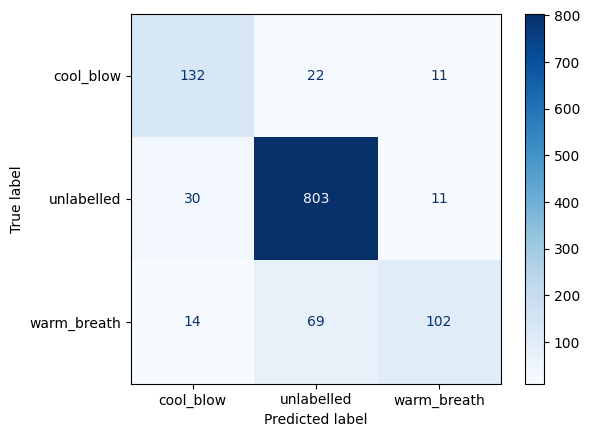

Accuracy for class 'cool_blow': 0.80
Accuracy for class 'unlabelled': 0.95
Accuracy for class 'warm_breath': 0.55


In [11]:
# Test the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)

# Print confusion matrix on multi class classification:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')
plt.show()

# Print the per-class accuracy:
for i, class_label in enumerate(label_encoder.classes_):
    class_indices = np.where(y_true == i)[0]
    class_accuracy = np.sum(y_pred[class_indices] == i) / len(class_indices)
    print(f"Accuracy for class '{class_label}': {class_accuracy:.2f}")

## Training model #2 - No 'unlabelled' classes

In [12]:
# This code will analyz each data sample, and it will extract windows from the available data. This is th logic applied:
# - Data is windowed sequentially with specified window size and overlap;
# - Each window is associated with a label among "cool_blow", "warm_breath", or "unlabelled" based on the labels file. 
# - If a window overlaps with multiple events, the label with the longest overlap is assigned to the window.
# - If last window is shorter than window size, it is discarded.

window_size_seconds = 1.5
overlap_seconds = 0.5
Fs = 64
class_to_exclude = 'warm_breath'

extracted_windows, extracted_labels = extract_windows_with_labels(train_data_df_list, train_label_df_list, window_size_seconds, overlap_seconds, Fs)
            
print(f"Extracted {len(extracted_windows)} windows from the dataset.")
# Print length of each window:
for w in extracted_windows:
    print(f"Window length (samples): {w.shape[0]}, features: {w.shape[1]}")

# Create X_data and y_data numpy arrays for ML model training. Keep in mind that each window is an array with (timesteps, features) and we want to processs them
# with Conv1D or LSTM models, so we will keep the 2D shape (timesteps, features).
X_train = np.array(extracted_windows)
y_train = np.array(extracted_labels)

# Drop all samples belonging to 'unlabelled' class
mask = y_train != class_to_exclude
X_train = X_train[mask]
y_train = y_train[mask]

# Convert labels to integer encoding for softmax classification:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)

# Set labels as one-hot encoding for softmax classification:

y_train = to_categorical(y_train)

# Check shape
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

# Do the same for test and validation:
extracted_test_windows, extracted_test_labels = extract_windows_with_labels(test_data_df_list, test_label_df_list, window_size_seconds, overlap_seconds)

# Create X_data and y_data numpy arrays for ML model training. Keep in mind that each window is an array with (timesteps, features) and we want to processs them
# with Conv1D or LSTM models, so we will keep the 2D shape (timesteps, features).
X_test = np.array(extracted_test_windows)
y_test = np.array(extracted_test_labels)

# Drop all samples belonging to 'unlabelled' class
mask = y_test != class_to_exclude
X_test = X_test[mask]
y_test = y_test[mask]

# Convert labels to integer encoding for softmax classification:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_test = label_encoder.fit_transform(y_test)

# To categorical

y_test = to_categorical(y_test)

# Print interface of label encoder to check which integer corresponds to which label:
print("Label encoding mapping:")
for i, class_label in enumerate(label_encoder.classes_):
    print(f"Integer {i} -> Label '{class_label}'")


# Take 50% for validation from test set:
val_size = int(0.5 * len(X_test))
X_val = X_test[:val_size]
y_val = y_test[:val_size]
X_test = X_test[val_size:]
y_test = y_test[val_size:]

# Check shape
print(f"X_test shape: {X_test.shape}")
print(f"X_val shape: {X_val.shape}")

Extracted 3163 windows from the dataset.
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (samples): 96, features: 2
Window length (s

In [13]:
model_2 = create_model(n_classes=2)

# define early stopping callback
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
# Train the model
history = model_2.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_val, y_val), callbacks=[early_stopping])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 94, 32)         │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 47, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 45, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        90,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,738 (377.88 KB)

 Trainable params: 96,738 (377.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6926 - loss: 0.5997 - val_accuracy: 0.7212 - val_loss: 0.4883
Epoch 2/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6926 - loss: 0.5997 - val_accuracy: 0.7212 - val_loss: 0.4883
Epoch 2/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7556 - loss: 0.4784 - val_accuracy: 0.8040 - val_loss: 0.3906
Epoch 3/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7556 - loss: 0.4784 - val_accuracy: 0.8040 - val_loss: 0.3906
Epoch 3/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7871 - loss: 0.4231 - val_accuracy: 0.8176 - val_loss: 0.3506
Epoch 4/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7871 - loss: 0.4231 - val_accuracy: 0.8176 - val_loss: 0.3506
Epoch 4/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8072 - loss: 0.3933 - val_accuracy: 0.8166 - val_loss: 0.3369
Epoch 5/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8072 - loss: 0.3933 - val_accu

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9361 - loss: 0.1535
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9361 - loss: 0.1535
Test loss: 0.15347468852996826
Test accuracy: 0.936125636100769
Test loss: 0.15347468852996826
Test accuracy: 0.936125636100769
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


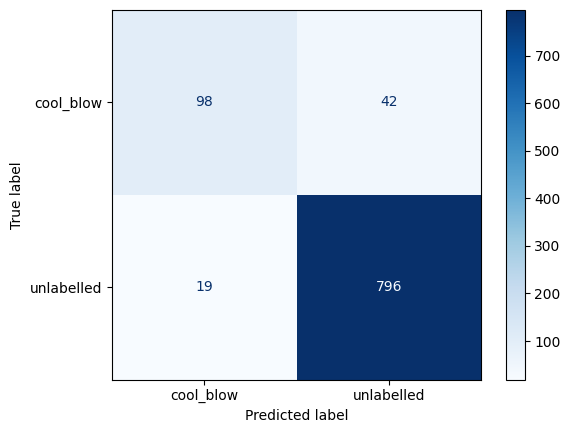

Accuracy for class 'cool_blow': 0.70
Accuracy for class 'unlabelled': 0.98


In [14]:
# test the model on the test set
test_loss, test_accuracy = model_2.evaluate(X_test, y_test)
print(f"Test loss: {test_loss}")
print(f"Test accuracy: {test_accuracy}")

# Print confusion matrix on 2-class classification:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred_probs = model_2.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')
plt.show()

# Print per-class accuracy:
for i, class_label in enumerate(label_encoder.classes_):
    class_indices = np.where(y_true == i)[0]
    class_accuracy = np.sum(y_pred[class_indices] == i) / len(class_indices)
    print(f"Accuracy for class '{class_label}': {class_accuracy:.2f}")